# 04｜组件对比实验

每次只替换一个组件，其余条件保持一致。每一列对应一种设置，
从上到下依次查看决策边界、Loss、Accuracy 和梯度。

In [1]:
%matplotlib inline
from pathlib import Path
import sys

LAB_DIR = Path.cwd()
if not (LAB_DIR / "mlp_lab").is_dir():
    LAB_DIR = (Path.cwd() / "01_mlp_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

from mlp_lab import compare

## 对比激活函数

共享服务器默认使用 CPU。只有获得课堂分配后，才使用第 `x` 块 GPU。


配置对比
--------------------------------------------------------------------------------------
配置                                   测试准确率         参数量       耗时(秒)          末轮梯度
--------------------------------------------------------------------------------------
激活函数：relu                           93.3%       1,218        0.10         0.237
激活函数：tanh                           93.3%       1,218        0.10        0.2454
激活函数：sigmoid                        91.1%       1,218        0.10        0.1098
--------------------------------------------------------------------------------------


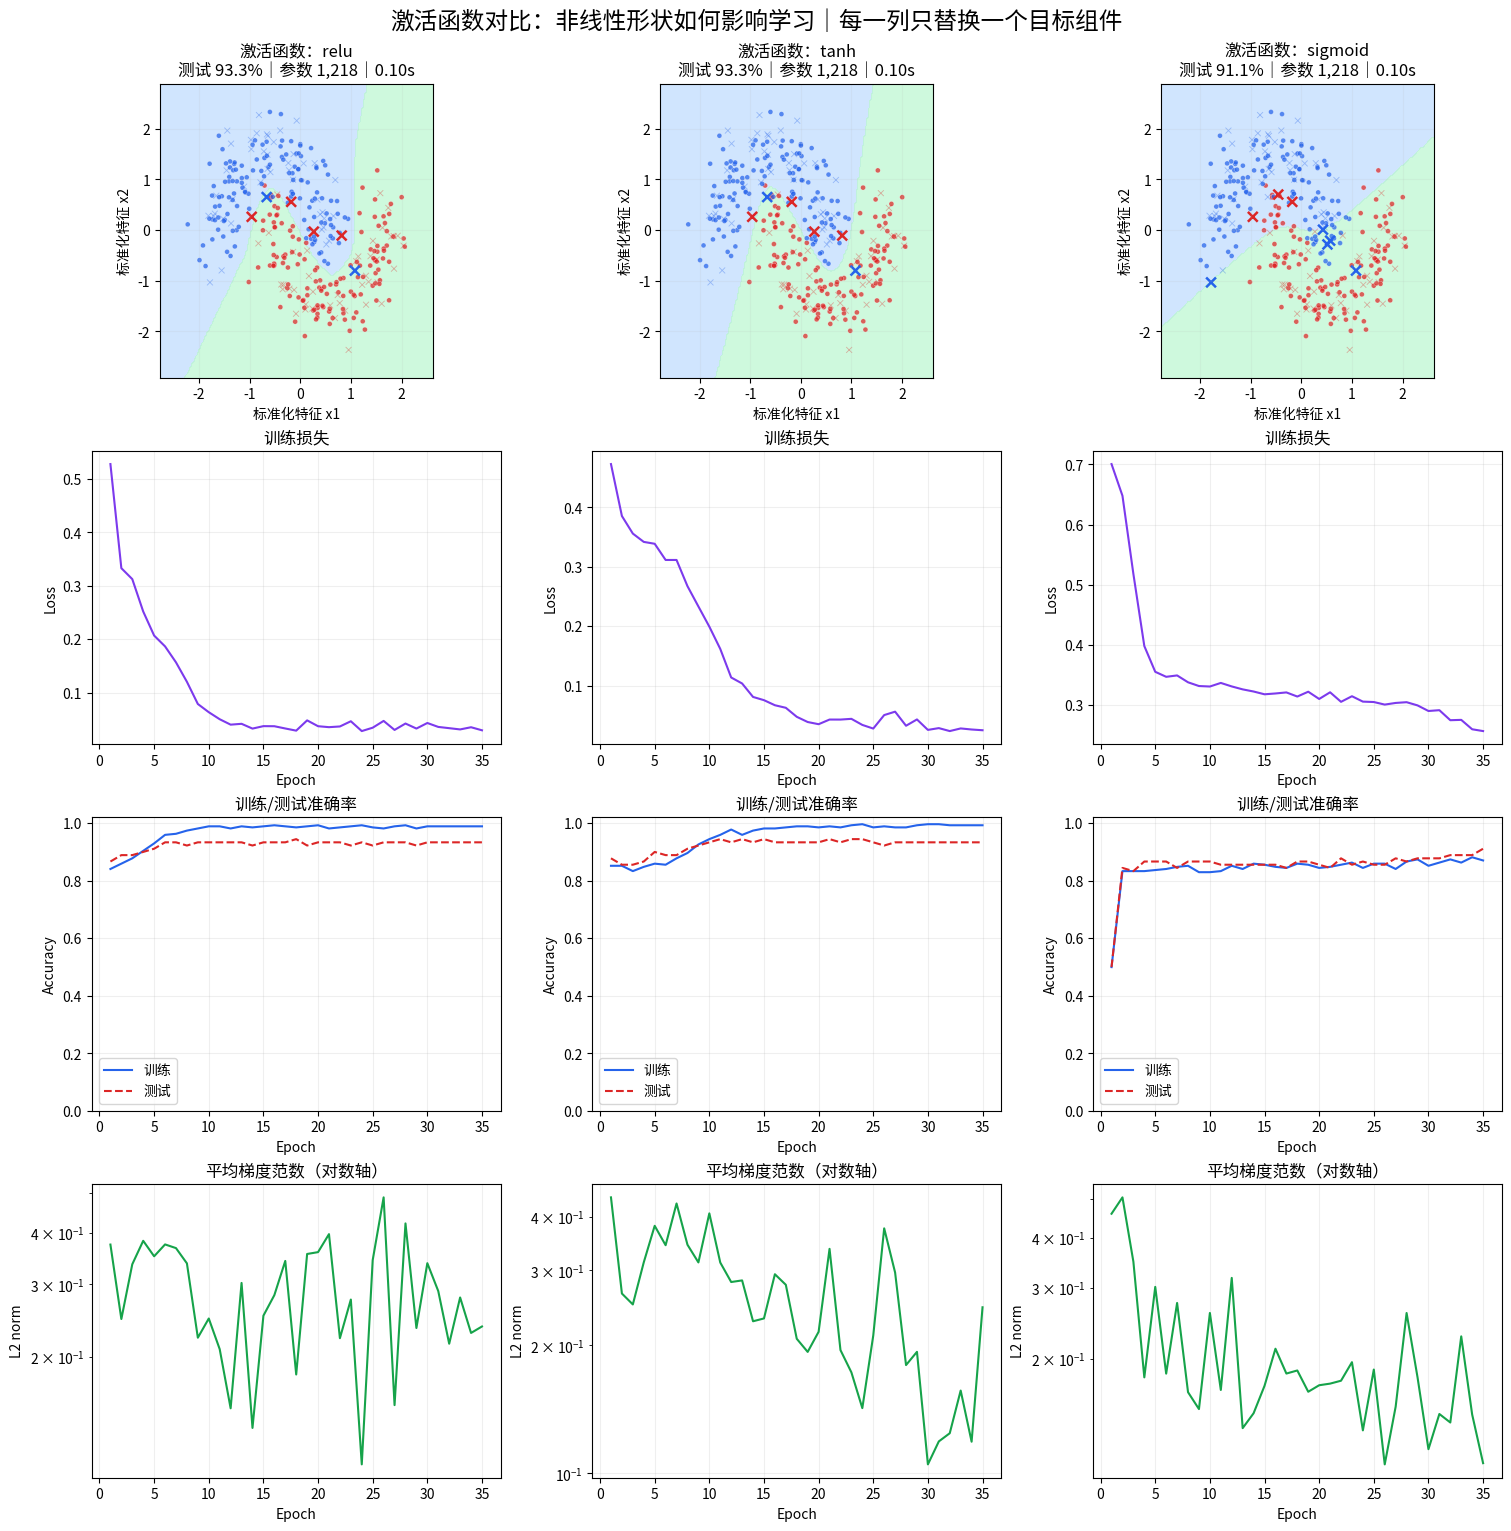

In [2]:
DEVICE = "cpu"
# 使用第 x 块 GPU 时改为 DEVICE = "cuda:x"，并把 x 替换为课堂指定编号。

activation_results = compare(
    "activation", dataset="moons", device=DEVICE, epochs=35, n_samples=360
)

## 对比优化器


配置对比
--------------------------------------------------------------------------------------
配置                                   测试准确率         参数量       耗时(秒)          末轮梯度
--------------------------------------------------------------------------------------
优化器：sgd                             84.4%       1,218        0.08        0.2233
优化器：momentum                        91.1%       1,218        0.08        0.2094
优化器：adam                            93.3%       1,218        0.10         0.237
--------------------------------------------------------------------------------------


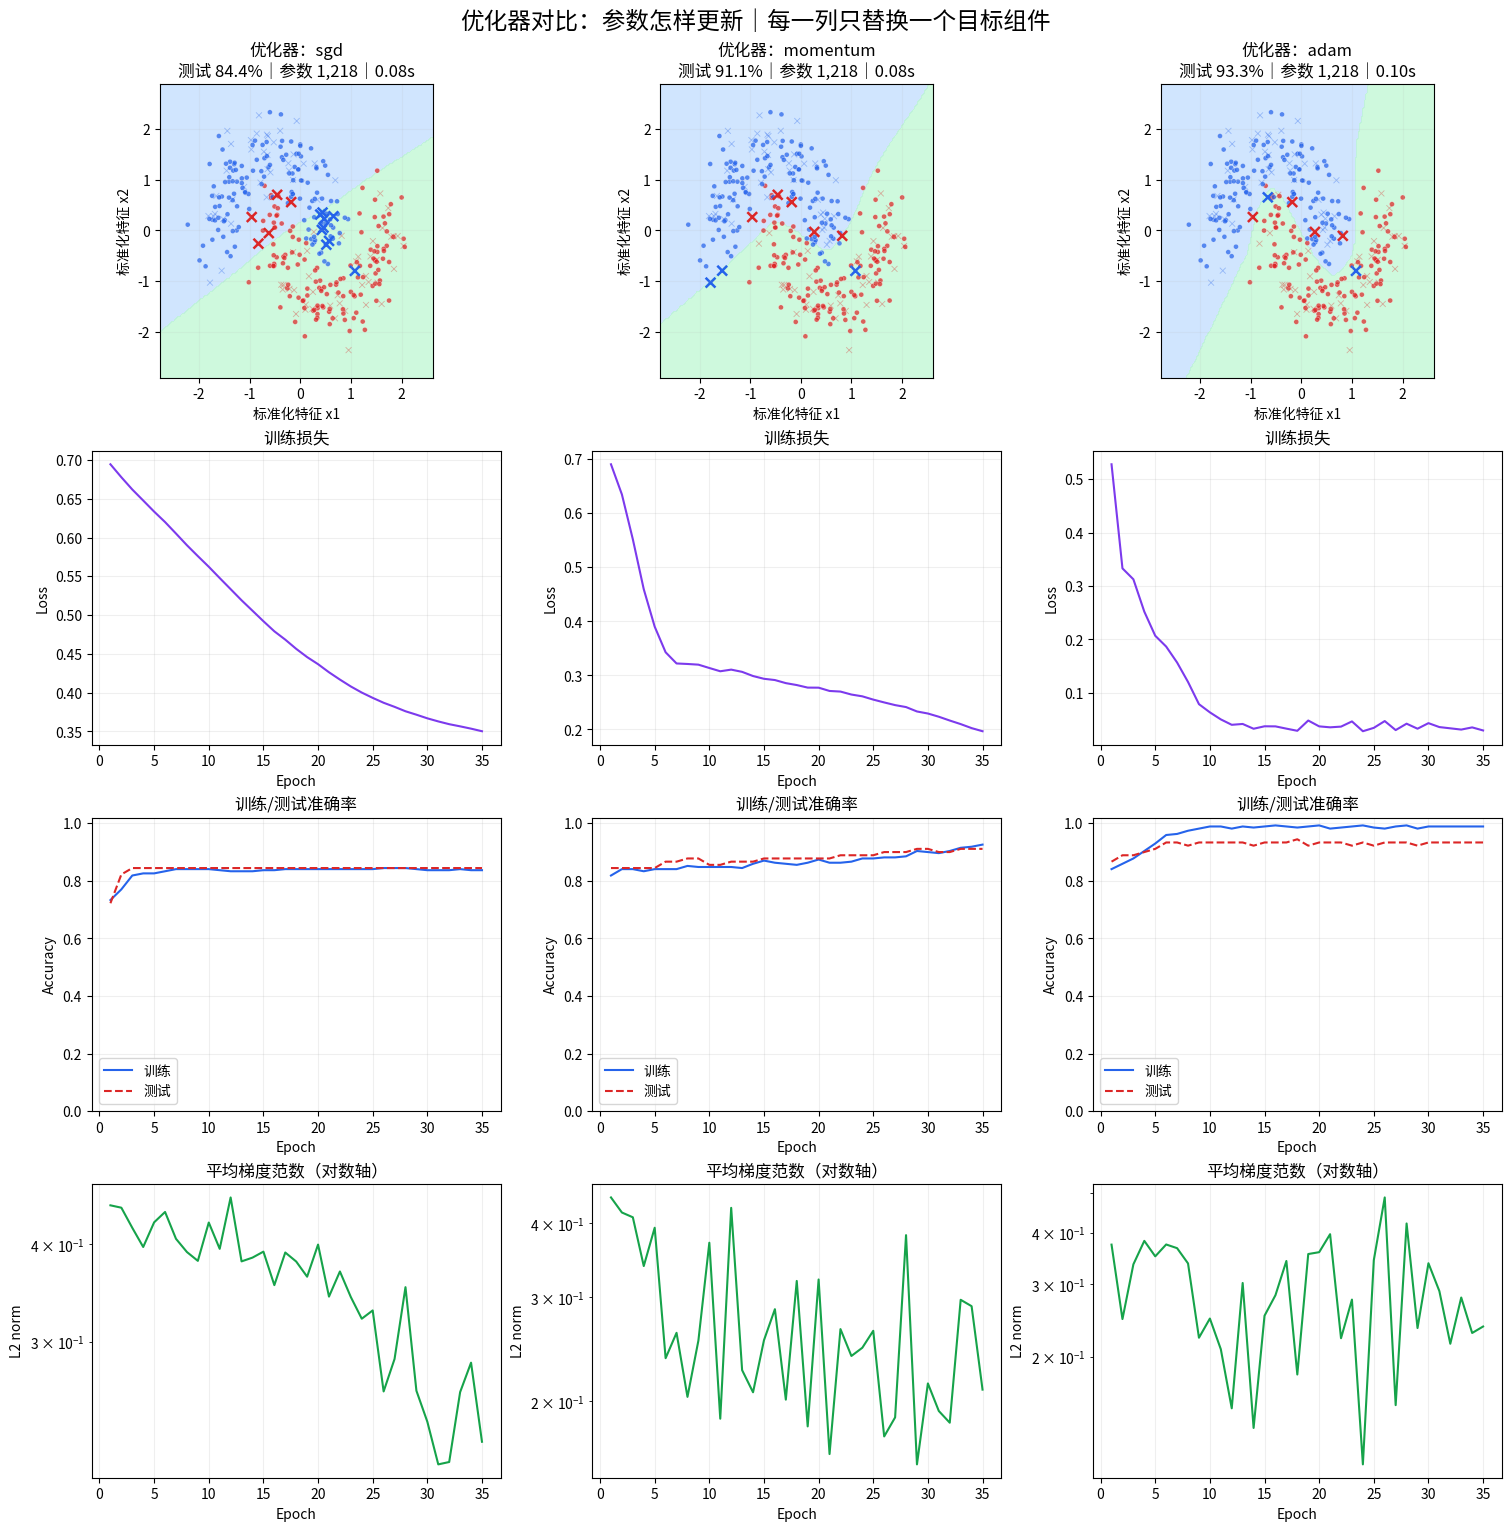

In [3]:
optimizer_results = compare(
    "optimizer", dataset="moons", device=DEVICE, epochs=35, n_samples=360
)

**记录要求：**不要只写“哪个准确率最高”。还要指出边界形状、收敛速度、
训练/测试差距，以及结论所依赖的数据与训练轮数。

## 完成本页后：释放资源并结束内核

运行下面的最后一个单元格。它会依次清空变量、关闭图片、释放未使用的 CUDA 缓存，并向 Jupyter 内核发送正常关机请求。

运行后，VS Code 可能显示“内核已停止”“请选择内核”或暂时断开连接，这是正常现象，表示当前 Notebook 的 Python 进程已经结束。再次实验时，重新选择 Python 内核即可。

In [4]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()

# 先释放当前进程中未使用的 CUDA 缓存。
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("清理完成，正在结束当前 Notebook 的 Python 内核……")

# 正常关闭当前 Jupyter 内核；再次运行时需要重新选择内核。
get_ipython().kernel.do_shutdown(restart=False)


清理完成，正在结束当前 Notebook 的 Python 内核……


{'status': 'ok', 'restart': False}